<a href="https://colab.research.google.com/github/BasithMrasak/audio-event-detection/blob/main/audio_event_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os


dataset_path = '/content/drive/MyDrive/ESC-50-master'


print(f"Contents of '{dataset_path}':")
for item in os.listdir(dataset_path):
    print(item)

Contents of '/content/drive/MyDrive/ESC-50-master':
esc50.gif
LICENSE
tests
.circleci
meta
.github
audio
.gitignore
README.md
requirements.txt
pytest.ini


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import os

In [10]:
metadata_csv = "/content/drive/MyDrive/ESC-50-master/meta/esc50.csv"
df = pd.read_csv(metadata_csv)

In [11]:
print("ESC-50: Number of classes       :", df['category'].nunique())
print("ESC-50: Total audio samples     :", len(df))
print("\nSample head of metadata:")
display(df.head())

ESC-50: Number of classes       : 50
ESC-50: Total audio samples     : 2000

Sample head of metadata:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


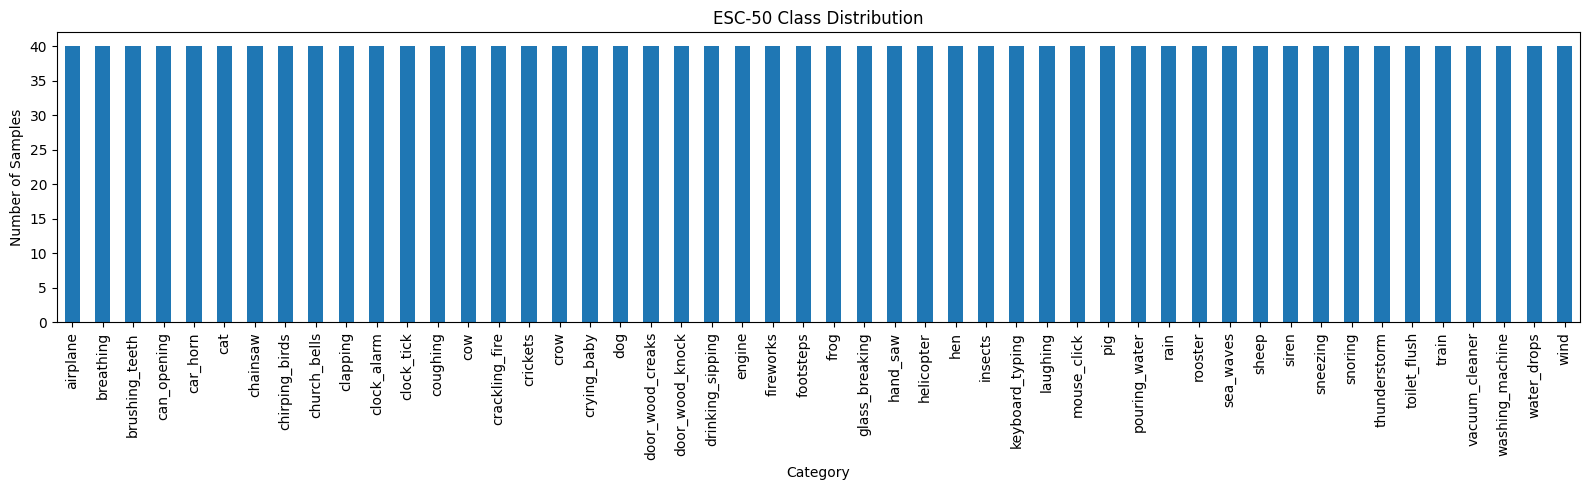

In [12]:
# Class Balance
class_counts = df['category'].value_counts().sort_index()
plt.figure(figsize=(16, 5))
class_counts.plot(kind="bar")
plt.title("ESC-50 Class Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [14]:
print("\nClass balance table:")
display(class_counts)


Class balance table:


,count
category,
airplane,40
breathing,40
brushing_teeth,40
can_opening,40
car_horn,40
cat,40
chainsaw,40
chirping_birds,40
church_bells,40


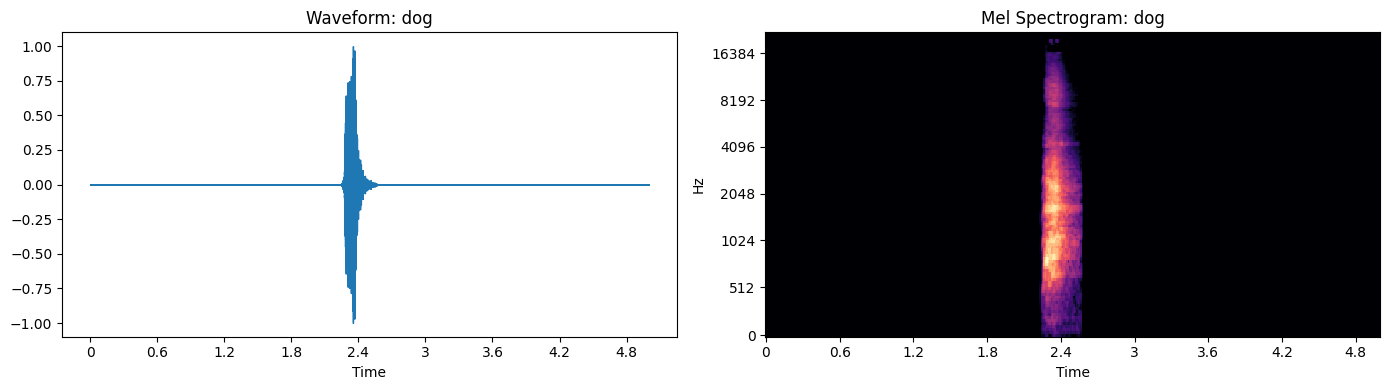

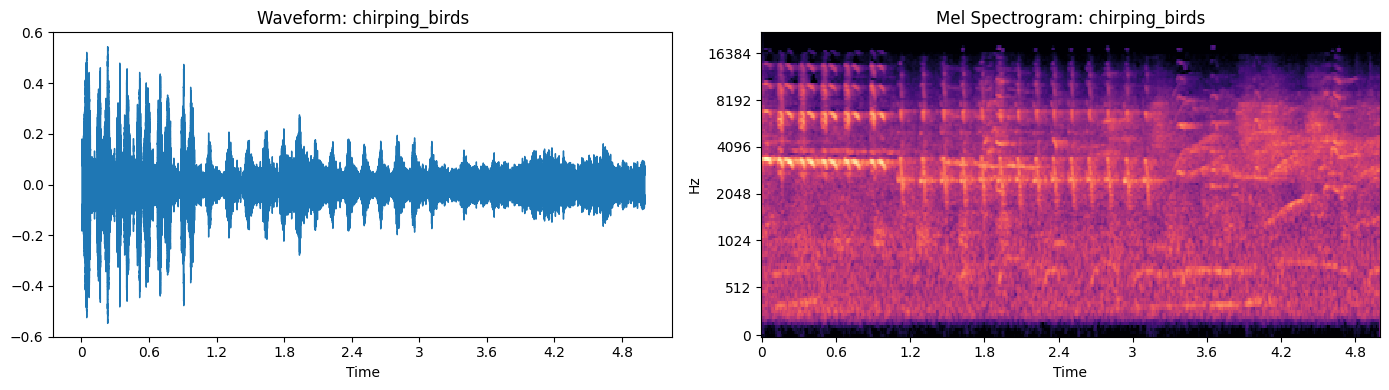

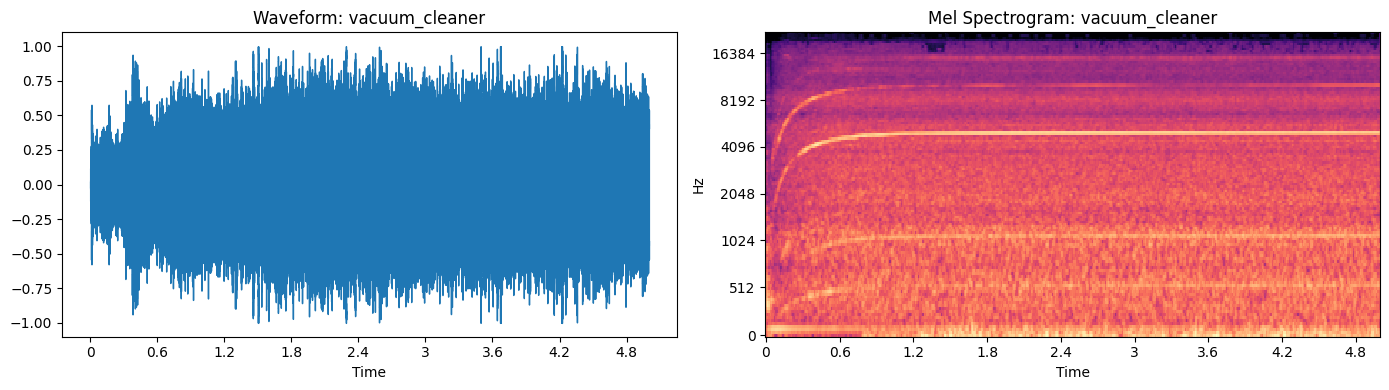

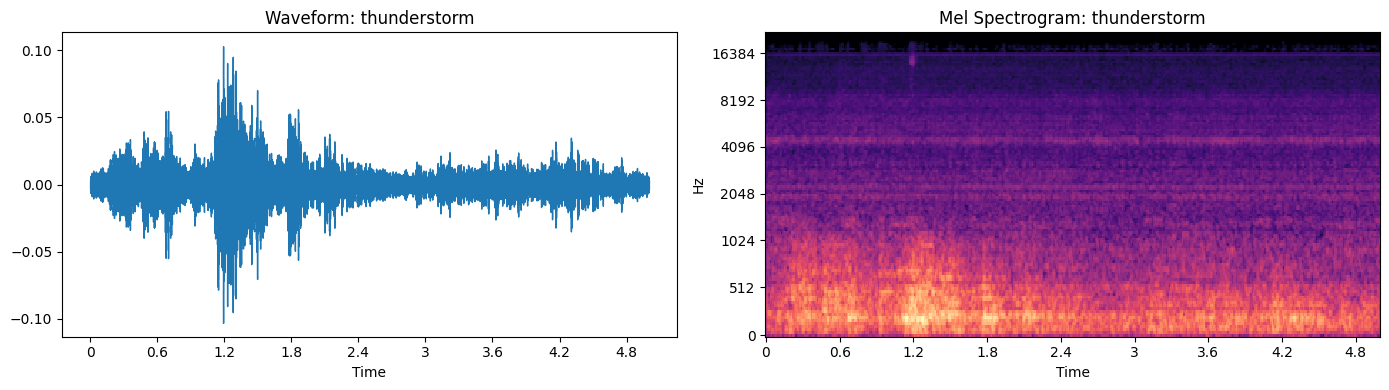

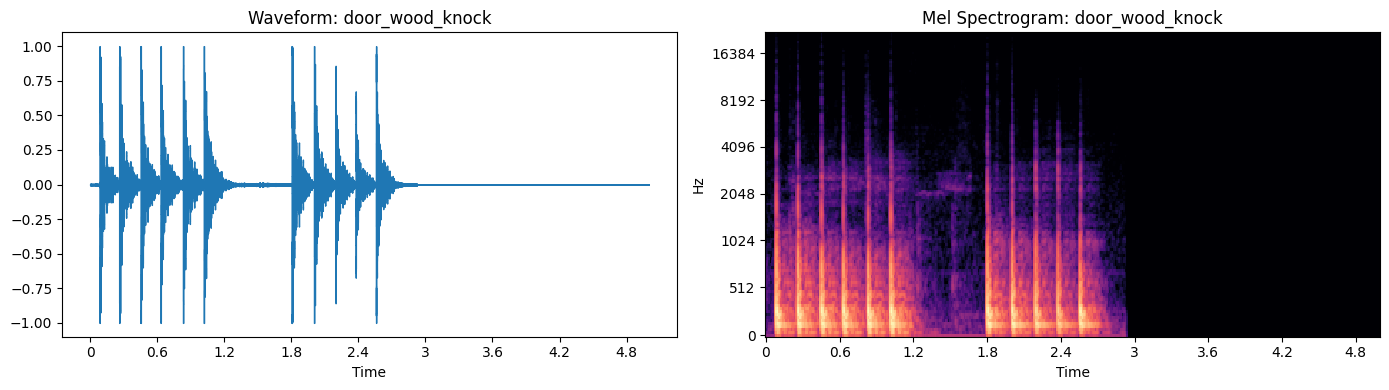

In [23]:
import numpy as np

audio_dir = os.path.join(dataset_path, 'audio')

for cls in classes_to_visualize:
    # Construct the full path to the audio file correctly
    file_path = os.path.join(audio_dir, df[df['category'] == cls].iloc[0]['filename'])
    audio, _ = librosa.load(file_path, sr=sr)
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    librosa.display.waveshow(audio, sr=sr)
    plt.title(f"Waveform: {cls}")

    plt.subplot(1, 2, 2)
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.title(f"Mel Spectrogram: {cls}")
    plt.tight_layout()
    plt.show()

In [24]:
decoder = dict(df[['target', 'category']].drop_duplicates().values)

print("Decoder dictionary created:")
print(decoder)

Decoder dictionary created:
{0: 'dog', 14: 'chirping_birds', 36: 'vacuum_cleaner', 19: 'thunderstorm', 30: 'door_wood_knock', 34: 'can_opening', 9: 'crow', 22: 'clapping', 48: 'fireworks', 41: 'chainsaw', 47: 'airplane', 31: 'mouse_click', 17: 'pouring_water', 45: 'train', 8: 'sheep', 15: 'water_drops', 46: 'church_bells', 37: 'clock_alarm', 32: 'keyboard_typing', 16: 'wind', 25: 'footsteps', 4: 'frog', 3: 'cow', 27: 'brushing_teeth', 43: 'car_horn', 12: 'crackling_fire', 40: 'helicopter', 29: 'drinking_sipping', 10: 'rain', 7: 'insects', 26: 'laughing', 6: 'hen', 44: 'engine', 23: 'breathing', 20: 'crying_baby', 49: 'hand_saw', 24: 'coughing', 39: 'glass_breaking', 28: 'snoring', 18: 'toilet_flush', 2: 'pig', 35: 'washing_machine', 38: 'clock_tick', 21: 'sneezing', 1: 'rooster', 11: 'sea_waves', 42: 'siren', 5: 'cat', 33: 'door_wood_creaks', 13: 'crickets'}
